In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");

else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

# [ 1.00000000e+06,  1.00000000e+04,  9.00000000e-01,
#          2.85813146e+01,  5.00000000e-01,  1.00000000e+00,
#          3.31765439e+01,  1.04719755e+00,  7.85398163e-01,
#          6.28318531e-01,  5.23598776e-01,  1.00000000e-01,
#          2.00000000e-01,  3.00000000e-01,  1.00000000e+01,
#          2.50000000e-01,  9.50000000e-01]

m1 = 1e6
m2 = 1e4
a = 0.9 
p0 = 2.85813146e+01
#p0 = 42.0
e0 = 5.00000000e-01
xI0 = 1.0
dist = 3.31765439e+01
#dist = 5.0
qS = 1.04719755e+00
phiS = 7.85398163e-01
qK = 6.28318531e-01

phiK =5.23598776e-01
Phi_phi0 = 0.1
Phi_theta0 =0.2
Phi_r0 = 0.3

dt = 10.0
T = 0.25
chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


should take p0 around for for true waveform:  40.469193718678454
separatrix p:  2.833236366839065
[0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


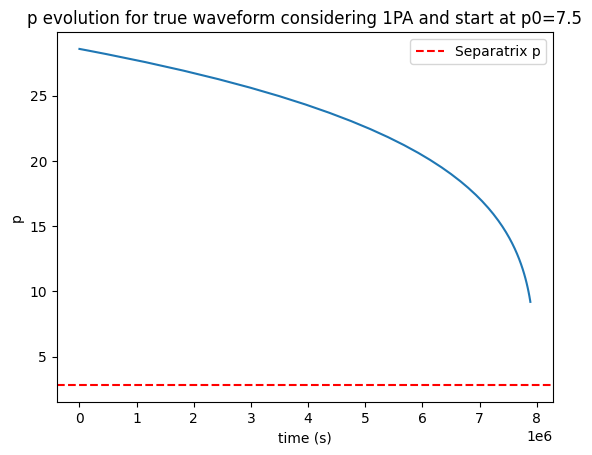

In [4]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a, e0, xI0)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=1.0, traj_args=[m1, m2, a, e0, xI0, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1, m2, a, p0, e0, xI0, *add_args,
                                               Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

In [5]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 788954)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10000.0, 0.9, 28.5813146, 0.5, 1.0, 33.1765439, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  10.095715195450351


In [6]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


Body is not plunging, Fisher should be stable.
waveform shape: (2, 788954)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10000.0, 0.9, 28.5813146, 0.5, 1.0, 33.1765439, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 10.095715195450351
The optimal source SNR is <= 20. The Fisher approximation may not be valid!
calculating stable deltas...
Gamma_ii for m1: 3.7788431231419835
Gamma_ii for m1: 3.778843122973602
Gamma_ii for m1: 3.778843122816341
Gamma_ii for m1: 3.7788431227448838
Gamma_ii for m1: 3.778843123088872
Gamma_ii for m1: 3.778843124539227


KeyboardInterrupt: 

In [7]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])

In [8]:

deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true

[0.95, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


array([[3.96861841e-21, 4.16719730e-21, 4.36100065e-21, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.05672296e-20, 1.04384767e-20, 1.03065012e-20, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(2, 3155815))

In [9]:

deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_):
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,\
                dev0p_,dev0e_,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    #print(diff_inner)
    return -0.5 * diff_inner



In [10]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
        m1_ = np.exp(logm1_)

        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_)
        log_likes[i] = loglike 
    return log_likes

n=30

logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
dev0plim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
dev0elim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]
    transformed[:, 9] = (dev0plim[1] - dev0plim[0]) * u[:, 9] + dev0plim[0]
    transformed[:, 10] = (dev0elim[1] - dev0elim[0]) * u[:, 10] + dev0elim[0]

    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])
    u[:, 9] = (x[:, 9] - dev0plim[0]) / (dev0plim[1] - dev0plim[0])
    u[:, 10] = (x[:, 10] - dev0elim[0]) / (dev0elim[1] - dev0elim[0])
    
    return u

In [ ]:
# def main():
    
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    cov_jitter=1e-10
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 11
n_seed = int(1e4)  # Number of initial processes
# n_seed = 10  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_manin_t_1_1e4'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")
# sampler.prepare_lhs_samples(lhs_num=int(5e4), batch_size=50)
# x = np.linspace(0.49999, 0.50001, 2000)

# # Generate 99 random points in 11D
# external_lhs_points = np.random.choice(x, size=(99, 11))

# # Add the "true point" [0.5, 0.5, ..., 0.5] as the 100th point
# external_lhs_points = np.vstack([external_lhs_points, [0.5]*11])

#best value got so far
true_point = np.array([[0.5 , 0.50  ,0.5 ,0.5, 0.5 ,0.5,
 0.5, 0.5, 0.5 ,0.5,  0.5]])



rng = np.random.default_rng(42)
scatter = 1.0e-6
points = true_point + rng.normal(size=(n_seed-1, 11)) * scatter

# Add the original point as the 100th row
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


# external_lhs_points = np.vstack(external_lhs_points)
# external_lhs_log_densities = np.concatenate(external_lhs_log_densities)

sampler.run_sampling(
            num_iterations=int(1e4),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )
#except Exception as exc:
 #       print(f"[WARN] PARIS sampling failed: {exc}")
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")


Problem dimension: 11
Number of processes: 10000
Save path: paris_manin_t_1_1e4
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
Shape of points array: (10000, 11)


KeyboardInterrupt: 

In [11]:
best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
print(np.max(external_lhs_log_densities))
print(best_fit_tn)

prior_transform(np.array([best_fit_tn]))

NameError: name 'external_lhs_points' is not defined


# array([-1143.85089403]) -> 0.009894015461101779
## [ 1.38160766e+01,7.73822653e+03,-9.00403425e-01,4.20592997e+01,5.00023850e-01,1.60761888e+00,1.82033956e+00,2.62943353e-01,2.14856425e-01,-1.53535661e-01,2.34228475e-02]

# array([-1142.58611995]) -> 0.005658946534629341

## [ 1.38200811e+01,6.33238062e+03,-8.96151413e-01,4.21591531e+01,4.99958263e-01,1.76591062e+00,1.08140575e+00,1.55045250e-01,3.95573277e-01,-2.28156450e-01,-1.62510561e-03]

In [14]:
print(log_density([params_truth_in]))
log_density([[ 1.38160766e+01,7.73822653e+03,-9.00403425e-01,4.20592997e+01,5.00023850e-01,1.60761888e+00,1.82033956e+00,2.62943353e-01,2.14856425e-01,-1.53535661e-01,2.34228475e-02]])

[-1956.87620169]


array([-1143.85089403])

# RANDOM SEED
42 (1e-7)


#

In [29]:
inverse_prior_transform(np.array([ [ 1.38160766e+01,7.73822653e+03,-9.00403425e-01,4.20592997e+01,5.00023850e-01,
               1.60761888e+00,1.82033956e+00,2.62943353e-01,2.14856425e-01,-1.53535661e-01,2.34228475e-02]]))

array([[0.51051301, 0.22461226, 0.49725253, 0.54763941, 0.50547291,
        0.76256125, 0.77745157, 0.51896936, 0.47912335, 0.31114353,
        0.52881494]])

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim,dev0plim,dev0elim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)

labels = [
    "logm1", "m2", "a", "p0", "e0",
    "qS", "phiS", "Phi_phi0", "Phi_r0",
    "dev0p", "dev0e"
]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=25,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [ ]:
def summarize(sampler: Sampler) -> None:
    print("Sampler State")
    print("-------------")
    print(f"ndim: {sampler.ndim}")
    print(f"n_proc: {sampler.n_seed}")
    print(f"current_iter: {getattr(sampler, 'current_iter', None)}")
    print(f"savepath: {getattr(sampler, 'savepath', '(unset)')}")
    
state_path = '/home/svu/e1583490/paris_manin_t_1_near_separtrix_7/sampler_state.pkl'
if not os.path.isfile(state_path):
    print(f"Sampler state not found at: {state_path}")
    print("Please run the multimodal example first:")
    print("  python examples/multimodal_example.py")
    raise FileExistsError(f"State file not found: {state_path}")


sampler = Sampler.load_state(state_path)

# Optionally, rebind the functions to the wrappers for clarity
# (unpickling may already have set them to these wrappers).
try:
        sampler.log_density_func_original = log_density
        if hasattr(sampler, "prior_transform") and sampler.prior_transform is not None:
            sampler.prior_transform = prior_transform
        # If prior_transform was set, ensure transformed log-density hook is in place
        if getattr(sampler, "prior_transform", None) is not None:
            sampler.log_density_func = sampler.transformed_log_density_func
        else:
            sampler.log_density_func = sampler.log_density_func_original
        print("Rebound functions after loading state.")
except Exception:
        # Keep going even if attributes differ in older states
        pass

print("Loaded state. Summary before resume:")
summarize(sampler)

    # Continue sampling
print("\nResuming sampling...")
sampler.run_sampling(
num_iterations=int(1e4),
        savepath="paris_manin_t_05_cov14_30k",
        print_iter=200,
        stop_dlogZ=0.01,
    )

print("\nResume completed. Summary after resume:")
summarize(sampler)

    # Optional: quick analysis similar to load_sampler_example
try:
        import numpy as np
        samples, weights = sampler.get_samples_with_weights(flatten=True)
        ess = 1.0 / (weights ** 2).sum()
        wmean = (samples * weights[:, None]).sum(axis=0) / weights.sum()
        print("\nQuick analysis")
        print("--------------")
        print(f"Total samples: {len(samples)}")
        print(f"Effective sample size (ESS): {ess:.1f}")
        print(f"Weighted mean (first 5 dims): {wmean[:5]}")
except Exception as e:
        print(f"Analysis skipped: {e}")


In [ ]:
wmean

In [ ]:
print(f"Weighted mean (first 5 dims): {wmean[:]}")

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim,dev0plim,dev0elim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)
labels = [
    "logm1", "m2", "a", "p0", "e0",
    "qS", "phiS", "Phi_phi0", "Phi_r0",
    "dev0p", "dev0e"
]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=20,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [ ]:
n=0.01
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
logm_range=np.linspace(logm1lim[0],logm1lim[1],1000)
val_m=[]

for i in logm_range:
    loglike=log_density(np.array([[i, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e]]))
    val_m.append(loglike)


In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[0],color='red')
plt.xlabel('logm1')
plt.ylabel('loglike')
plt.title('loglike vs logm1 (0.01 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=qS,color='red')
plt.xlabel('qS')
plt.ylabel('loglike')
plt.title('loglike vs qS (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=0,color='red')
plt.xlabel('dev_0_p')
plt.ylabel('loglike')
plt.title('loglike vs dev_0_p (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[4],color='red')
plt.xlabel('e0')
plt.ylabel('loglike')
plt.title('loglike vs e0 (1 std)')

In [ ]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')
covariance= np.linalg.inv(fisher_)
fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)


plt.tight_layout()
plt.show()


In [ ]:
from stableemrifisher.plot import CovEllipsePlot
import numpy as np
import matplotlib.pyplot as plt

pars_list = params_truth_in
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

# --- build wave_params dict (same as original) ---
wave_params = {param_names[i]: params_truth_in[i] for i in range(len(pars_list))}

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

# --- create subplots grid ---
fig, axs = plt.subplots(len(covariance), len(covariance), figsize=(20,20))

# --- Fisher covariance ellipse corner plot ---
fig, axs = CovEllipsePlot(
    covariance,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs,
    line_kwargs=line_kwargs
)

# === ADD TRUE PARAMETER LINES (existing behavior) ===
for i in range(len(param_names)):
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)

# === ADD 99% CONDITIONAL POSTERIOR LINES ON DIAGONAL ===
for i in range(len(param_names)):

    theta = params_truth_in.copy()  # reference conditioning point
    grid = np.linspace(param_ranges[i][0], param_ranges[i][1], 2000)
    logP = []

    for x in grid:
        theta[i] = x
        lp = log_density(np.array([theta]))
        logP.append(lp[0])


    logP = np.array(logP)
    P = np.exp(logP - logP.max())  # unnormalized conditional posterior
    P /= np.trapezoid(P, grid)         # normalize

    # build CDF and extract 0.5% and 99.5% quantiles
    cdf = np.cumsum(P)
    cdf /= cdf[-1]
    low_99  = grid[np.searchsorted(cdf, 0.005)]
    high_99 = grid[np.searchsorted(cdf, 0.995)]

    # plot the 99% lines on the diagonal subplot
    ax = axs[i, i]
    ax.axvline(low_99,  linestyle="--", lw=2, label="0.5% (conditional)")
    ax.axvline(high_99, linestyle="--", lw=2, label="99.5% (conditional)")
    ax.legend(fontsize=9)

    print(f"{param_names[i]:10s} 99% conditional interval → [{low_99:.6f}, {high_99:.6f}]")

plt.tight_layout()
plt.show()


In [ ]:
from stableemrifisher.plot import CovEllipsePlot
import numpy as np
import matplotlib.pyplot as plt

pars_list = params_truth_in
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

# dictionary for fisher ellipse plot (same content as original)
wave_params = {param_names[i]: params_truth_in[i] for i in range(len(pars_list))}

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

covariance = np.linalg.inv(fisher_)

# create subplot grid
fig, axs = plt.subplots(len(param_names), len(param_names), figsize=(20,20))

# fisher ellipse corner plot
fig, axs = CovEllipsePlot(
    covariance,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs,
    line_kwargs=line_kwargs
)

# === Plot conditional posterior scans for each parameter i, across entire row ===
for i in range(len(param_names)):

    theta = params_truth_in.copy()  # conditioning reference point
    grid = np.linspace(param_ranges[i][0], param_ranges[i][1], 2000)

    logP = []
    for x in grid:
        theta[i] = x
        lp = log_density(np.array([theta]))
        logP.append(lp[0])

    logP = np.array(logP)
    P = np.exp(logP - logP.max())  # conditional posterior density ∝ exp(logP)
    P /= np.trapz(P, grid)         # normalize

    # compute CDF and 99% quantiles (for the diagonal lines)
    cdf = np.cumsum(P)
    cdf /= cdf[-1]
    low99  = grid[np.searchsorted(cdf, 0.005)]
    high99 = grid[np.searchsorted(cdf, 0.995)]

    # --- plot the conditional probability curve on ALL panels in row i ---
    for j in range(len(param_names)):
        ax = axs[i, j]
        ax.plot(grid, P, lw=1.2)

        # On diagonal i,i we also draw the 99% lines + true line
        if i == j:
            ax.axvline(params_truth_in[i], color='k', lw=2, label='true')
            ax.axvline(low99,  linestyle='--', lw=2, label='0.5% cond')
            ax.axvline(high99, linestyle='--', lw=2, label='99.5% cond')
            ax.legend(fontsize=8)

        # label bottom axes only for last row
        if i == len(param_names)-1:
            ax.set_xlabel(param_names[j], fontsize=9)

        # label left axes only for first column
        if j == 0:
            ax.set_ylabel(f"P({param_names[i]} | others)", fontsize=9)

    print(f"{param_names[i]:10s} 99% conditional interval → [{low99:.6f}, {high99:.6f}]")

plt.tight_layout()
plt.show()


In [ ]:
params_truth_in

In [ ]:
[1.37395954e+01,1.02986893e+01,7.62115004e-01,7.50765922e+00,4.17729451e-01,8.56649609e-01,1.09156164e+00,5.84324383e-01,-1.35031994e-03,
-9.89602655e-02,7.60856375e-02]

In [ ]:
from scipy.optimize import minimize
minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)